In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from nltk.tokenize import word_tokenize
import string
from scipy.stats import linregress
import nltk
import os
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/pranav/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/pranav/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Zipf's Law for English Corpus

In [2]:
class ZipfLaw():
    def __init__(self, path):
        self.path = path



    def preprocess_text(self, text):
        text = text.lower()
        tokens = word_tokenize(text)
        tokens = [token for token in tokens if token not in string.punctuation
                and token.isalnum()]
        return tokens




    def calculate_frequencies(self, documents):
        all_tokens = []
        for doc in documents:
            tokens = self.preprocess_text(doc)
            all_tokens.extend(tokens)

        word_freq = Counter(all_tokens)
        return word_freq




    def plot_zipf_distribution(self):
        sorted_freq = sorted(self.word_freq.items(), key=lambda x: x[1], reverse=True)
        frequencies = [freq for word, freq in sorted_freq]
        ranks = list(range(1, len(frequencies) + 1))
        log_frequencies = np.log(frequencies)
        log_ranks = np.log(ranks)   
        plt.figure(figsize=(10, 6))
        plt.scatter(log_ranks, log_frequencies, alpha=0.5, label='Observed frequencies', color='orange')
        plt.plot(log_ranks, log_frequencies[0] - 1 * log_ranks, 'b', label='Zipf\'s law Ideal Behaviour Line(slope = -1)')
        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_frequencies)
        best_fit = intercept + slope * log_ranks
        plt.plot(log_ranks, best_fit, 'y-', label=f'Best fit line (slope={slope})')
        
        plt.title('Zipf\'s Law: ln(freq) vs ln(rank)')
        plt.xlabel('ln(rank)')
        plt.ylabel('ln(freq)')
        plt.grid(True)
        plt.legend()
        plt.show()




    def verifyZipfsLawForCorpus(self):
        with open(self.path, 'r', encoding='utf-8') as file:
            documents = json.load(file)
        
        self.word_freq = self.calculate_frequencies(documents)
        self.plot_zipf_distribution()

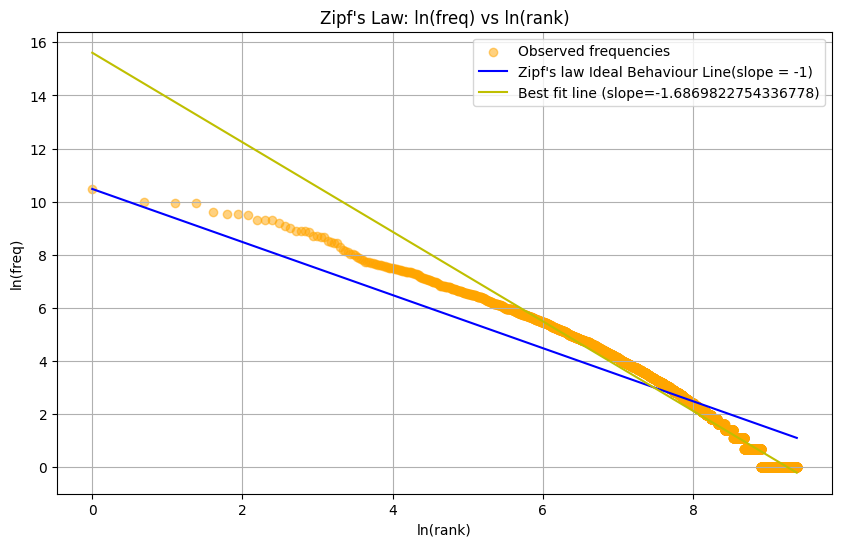

In [3]:
zipf_law = ZipfLaw('documents.json')
zipf_law.verifyZipfsLawForCorpus()

## 2. Decrypt Messages

### 2.1 Removing Noise

Mask.txt contains whether or not each of the message files are noisy or not. It is in the same folder as the Jupyter Notebook.

### 2.2 Decryption

In [4]:
class Decryption():
    def __init__(self, path, num_files):
        self.path = path
        self.num_files = num_files



    def read_file_words(self, filepath):
        with open(filepath, 'r') as f:
            return [line.strip() for line in f.readlines()]




    def detect_noisy_messages(self, filepath):
        word_freq = Counter(self.read_file_words(filepath))
        sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        frequencies = [freq for word, freq in sorted_freq]
        ranks = list(range(1, len(frequencies) + 1))
        
        log_frequencies = np.log(frequencies)
        log_ranks = np.log(ranks)
        slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_frequencies)
        return abs(slope) < 0.1      ####### threshold value indicates that having a slope in this range means that it is a uniform distribution, hence random messages and therefore a noisy image





    def create_encoded_shuffled_freq_dict(self, shuffled_filepath, encoded_filepath):
        shuffled_freq_dict = defaultdict(int)
        encoded_freq_dict = defaultdict(int)

        shuffled_words = self.read_file_words(shuffled_filepath)
        encoded_words = self.read_file_words(encoded_filepath)

        shuffled_words_set = set(shuffled_words)
        encoded_words_set = set(encoded_words)

        for word in shuffled_words:
            if word in shuffled_words_set-encoded_words_set:
                shuffled_freq_dict[word] += 1
        
        for word in encoded_words:
            if word in encoded_words_set-shuffled_words_set:
                encoded_freq_dict[word] += 1

        return shuffled_freq_dict, encoded_freq_dict






    def create_mapping(self, shuffled_freq, encoded_freq):
        sorted_shuffled = sorted(shuffled_freq.items(), key=lambda x: (-x[1], x[0]))
        sorted_encoded = sorted(encoded_freq.items(), key=lambda x: (-x[1], x[0]))
        mapping = {}
        for (encoded_word, _), (shuffled_word, _) in zip(sorted_encoded, sorted_shuffled):
            mapping[encoded_word] = shuffled_word
        return mapping





    def decode_message(self, input_file, output_file, mapping):
        encoded_words = self.read_file_words(input_file)
        decoded_message = '\n'.join(mapping.get(word, word) for word in encoded_words)
        with open(output_file, 'w') as f:
            f.write(decoded_message)




    def decrypt_messages(self):
        mask = []
        total_files = 5000

        for i in range(1, min(self.num_files, total_files)+1):
            shuffled_filepath = os.path.join(self.path, f"message_{i}_shuffled.txt")
            encoded_filepath = os.path.join(self.path, f"message_{i}_encoded.txt")

            if self.detect_noisy_messages(shuffled_filepath):
                mask.append(1)
                continue
            
            mask.append(0)
            shuffled_freq, encoded_freq = self.create_encoded_shuffled_freq_dict(shuffled_filepath, encoded_filepath)
            mapping = self.create_mapping(shuffled_freq, encoded_freq)
            output_filepath = os.path.join(self.path, f"message_{i}.txt")
            self.decode_message(encoded_filepath, output_filepath, mapping)
        
        mask_string = '\n'.join(str(x) for x in mask)
        with open('mask.txt', 'w') as f:
            f.write(mask_string)

In [5]:
decrypt = Decryption(path='./msgs', num_files=5000)
decrypt.decrypt_messages()

One thing to note in the above is that words which are present in the intersection of both shuflled_words_set and encoded_words_set have same frequency, ie. a word is either fully encrypted or not encrypted at all. This leads us to the conclusion that none of the messages are partially encrypted.

### 2.3 QnA

Q: You have made use of Zipf's Law for unigrams in this task. Would Zipf's Law for higher order n-grams give you any more information ?

Ans: No, Zipf's law would not provide any further information for higher order n-grams. It simply calculates the frequency of unigrams because it is based on the law of least effort. Additionally, because random messages have a more uniform frequency distribution and do not meet Zipf's law, unigrams made it easy to detect random noise.

Q: What region of tokens from the distribution would be helpful in retrieval systems ?

Ans: Since low-frequency tokens are extremely uncommon and could be typos, and high-frequency tokens, like stopwords, etc., are too generic, middle-frequency tokens would be more useful in retrieval systems.

Q: How did the mole help you in this task ? In particular, what was the property of the partial decryption he used that was key in your success ?

Ans: Partial decryption follows the property that either all occurences of a given token is decrypted or none is decrypted. This helped us in arriving to a direct frequency map between encrpted and unencryped tokens hence intercepting tokens with frequency matching.

Q: Was there any message that you were not able to decrypt ?

Ans: Decryption of the message file unbreakable_message could not be done since it contains some encrypted tokens with same frequencies which makes it unsuitable to decrypt with the property of frequency matching.

Q: Would Zipf’s Law work the way you have used it, if the given encryption scheme was not
bijective ?

Ans: Zipf's law was applied in order to identify loud communications. The original words in the file message_shuffled.txt were iterated. Since the words are shuffled, they should adhere to Zips' law and match the original message's frequency. A more consistent distribution of frequencies is the opposite of Zipf's law.
Therefore, even if the specified encryption method is not bijective, Zipf's Law would still function in the same manner because it only depends on frequency distribution.

## 3. Zipf's Law for Programming Languages

For this task, code available on github of scipy library of python was used. Use the command git clone https://github.com/scipy/scipy.git

In [6]:
import tokenize
import concurrent.futures

def tokenizeFile(file_path):
    try:
        with open(file_path, 'rb') as file:
            tokens_counter = Counter()
            
            try:
                # Tokenize the file
                for tok in tokenize.tokenize(file.readline):
                    # Skip encoding token
                    if tok.type == tokenize.ENCODING:
                        continue
                        
                    if tok.type == tokenize.INDENT:
                        tokens_counter['INDENT'] += 1
                    elif tok.type == tokenize.DEDENT:
                        tokens_counter['DEDENT'] += 1
                    elif tok.type == tokenize.NEWLINE or tok.type == tokenize.NL:
                        tokens_counter['NEWLINE'] += 1
                    else:
                        tokens_counter[tok.string] += 1
                        
            except tokenize.TokenError:
                print(f"Warning: TokenError in file {file_path}")
                
            return dict(tokens_counter)
            
    except Exception as e:
        print(f"Error processing file {file_path}: {str(e)}")
        return {}


def mergeFrequencyDicts(dict1, dict2):
    merged = dict1
    for key, value in dict2.items():
        merged[key] = merged.get(key, 0)+value
    return merged


def processRepository(repo_path, file_extension='.py'):
    python_files = []
    for root, _, files in os.walk(repo_path):
        for file in files:
            if file.endswith(file_extension):
                python_files.append(os.path.join(root, file))
    
    combined_frequencies = {}
    processed_files = 0
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        future_to_file = {executor.submit(tokenizeFile, file_path): file_path 
                         for file_path in python_files}
        
        for future in concurrent.futures.as_completed(future_to_file):
            file_path = future_to_file[future]
            try:
                file_frequencies = future.result()
                combined_frequencies = mergeFrequencyDicts(combined_frequencies, file_frequencies)
                processed_files += 1
                    
            except Exception as e:
                print(f"Error processing {file_path}: {str(e)}")
    
    return combined_frequencies


def verifyZipfsLawProgrammingLanguages(repo_path):
    word_freq = processRepository(repo_path)
    zipf_law = ZipfLaw('')
    zipf_law.word_freq = word_freq
    zipf_law.plot_zipf_distribution()
    return word_freq

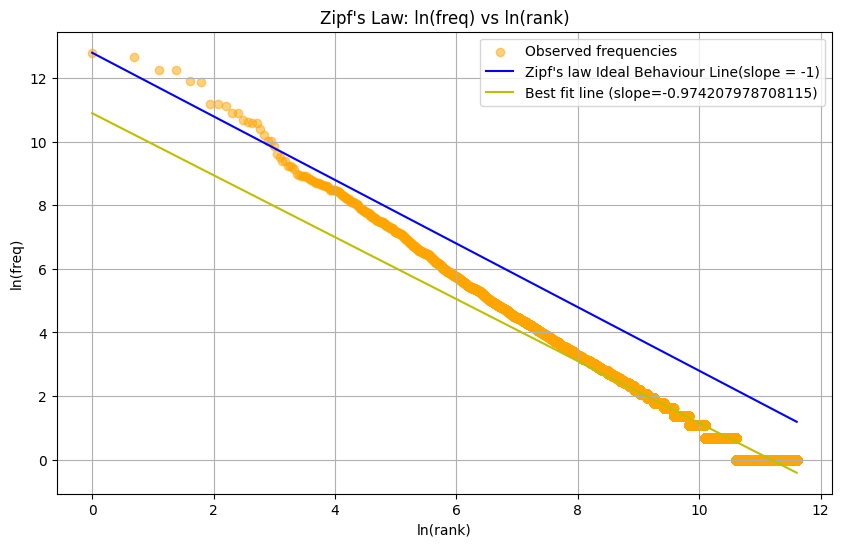

In [7]:
verifyZipfsLawProgrammingLanguages('./scipy')

Tokenization of programming languages result in token distribution as predicted by Zipf’s Law as is observed in the case of scipy library which also considers python special restrictions such as Indentation into account.